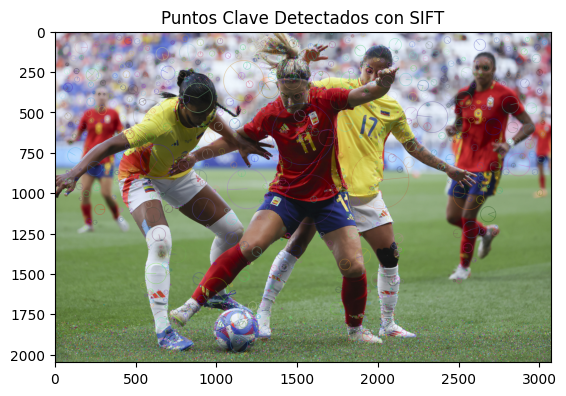

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("output", exist_ok=True)

# Cargar la imagen
img = cv2.imread('images/Escena_01.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Crear el objeto SIFT
sift = cv2.SIFT_create()

# Detectar puntos clave y calcular descriptores
keypoints, descriptors = sift.detectAndCompute(gray, None)

# Dibujar los puntos clave en la imagen
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
cv2.imwrite('output/ejemplo_01_keypoints.png', img_with_keypoints)
# Mostrar la imagen con puntos clave
plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title('Puntos Clave Detectados con SIFT')
plt.show()


In [3]:
import cv2
import os

os.makedirs("output", exist_ok=True)
# Crear el objeto SIFT con parámetros personalizados
sift = cv2.SIFT_create(
    nfeatures=500,        # Número de características a retener
    nOctaveLayers=3,      # Número de capas por octava
    contrastThreshold=0.04, # Umbral de contraste
    edgeThreshold=10,     # Umbral de borde
    sigma=1.6             # Sigma de la Gaussian utilizada para la detección de escala
)

# Cargar la imagen y convertirla a escala de grises
img = cv2.imread('images/Escena_01.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detectar puntos clave y calcular descriptores
keypoints, descriptors = sift.detectAndCompute(gray, None)

# Dibujar los puntos clave en la imagen
img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
cv2.imwrite('output/ejemplo_02_keypoints.png', img_with_keypoints)
# Mostrar la imagen con puntos clave
cv2.imshow('Puntos Clave Detectados con SIFT', img_with_keypoints)
cv2.waitKey(0)
cv2.destroyAllWindows()


8666


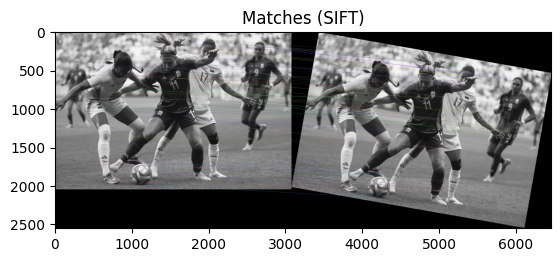

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("output", exist_ok=True)
# Cargar las imágenes
img1 = cv2.imread('images/Escena_01.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena A
img2 = cv2.imread('images/Escena_01_rotada_10_grados.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena B
#img2 = cv2.imread('images/Escena_01_rotada_90_grados.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena B
#img2 = cv2.imread('images/Escena_01.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena B

# Crear el objeto SIFT
sift = cv2.SIFT_create()

# Detectar puntos clave y calcular descriptores
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Usar BFMatcher para encontrar los mejores matches
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True) #En general estos parámetros son buenos para SIFT
                                                  
matches = bf.match(descriptors1, descriptors2)

# Ordenar los matches por distancia
matches = sorted(matches, key=lambda x: x.distance)
print(len(matches))
# Dibujar los primeros 10 matches
img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
cv2.imwrite('output/ejemplo_03_matches90.png', img_matches)
# Mostrar la imagen con los matches
cv2.imshow('Matches (SIFT)', img_matches)
cv2.waitKey(0)
cv2.destroyAllWindows()

plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title('Matches (SIFT)')
plt.show()



Matches encontrados: 7757


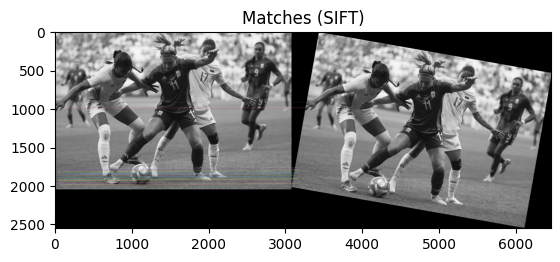

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("output", exist_ok=True)
# Cargar las imágenes
img1 = cv2.imread('images/Escena_01.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena A
img2 = cv2.imread('images/Escena_01_rotada_10_grados.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena B
#img2 = cv2.imread('images/Escena_01_rotada_90_grados.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena B
#img2 = cv2.imread('images/Escena_01.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena B

# Crear el objeto SIFT
sift = cv2.SIFT_create()

# Detectar puntos clave y calcular descriptores
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Usar BFMatcher para encontrar los mejores matches

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f'Matches encontrados: {len(good_matches)}')

img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, good_matches[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

cv2.imwrite('output/ejemplo_03_matches90_v2.png', img_matches)
# Mostrar la imagen con los matches
cv2.imshow('Matches (SIFT)', img_matches)
cv2.waitKey(0)
cv2.destroyAllWindows()

plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title('Matches (SIFT)')
plt.show()



222


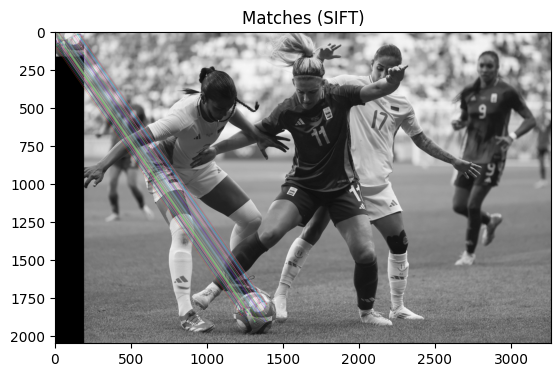

In [11]:
import cv2
import numpy as np
import os

os.makedirs("output", exist_ok=True)
# Cargar las imágenes
img1 = cv2.imread('images/Objeto_01.png', cv2.IMREAD_GRAYSCALE)  # Imagen del objeto
img2 = cv2.imread('images/Escena_01.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena

# Crear el objeto SIFT
sift = cv2.SIFT_create()

# Detectar puntos clave y calcular descriptores
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Usar BFMatcher para encontrar los mejores matches
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True) #En general estos parámetros son buenos para SIFT
                                                  
matches = bf.match(descriptors1, descriptors2)

# Ordenar los matches por distancia
matches = sorted(matches, key=lambda x: x.distance)
print(len(matches))

# Dibujar los primeros 10 matches
img_matches = cv2.drawMatches(img1, keypoints1,
                              img2, keypoints2,
                              matches[:100], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Mostrar la imagen con los matches
#cv2.imshow('Matches', img_matches)
#cv2.waitKey(0)
#cv2.destroyAllWindows()
cv2.imwrite('output/ejemplo1_escena_objeto.png', img_matches)
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title('Matches (SIFT)')
plt.show()




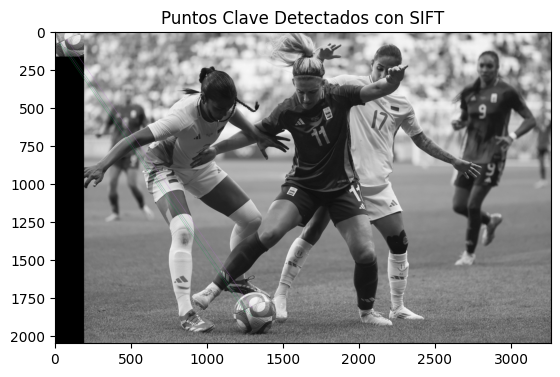

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("output", exist_ok=True)
# Cargar las imágenes
img1 = cv2.imread('images/Objeto_01.png', cv2.IMREAD_GRAYSCALE)  # Imagen del objeto
img2 = cv2.imread('images/Escena_02.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena

# Crear el objeto SIFT
#sift = cv2.SIFT_create()

# Crear el objeto SIFT con parámetros personalizados
sift = cv2.SIFT_create(
    nfeatures=1000,        # Número de características a retener
    nOctaveLayers=8,      # Número de capas por octava
    contrastThreshold=0.01, # Umbral de contraste
    edgeThreshold=5,     # Umbral de borde
    sigma=5.0             # Sigma de la Gaussian utilizada para la detección de escala
)

# Detectar puntos clave y calcular descriptores
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Usar BFMatcher para encontrar los mejores matches
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)

# Ordenar los matches por distancia
matches = sorted(matches, key=lambda x: x.distance)

# Dibujar los primeros 10 matches
img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:5], 
                              None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
cv2.imwrite('output/ejemplo2_escena_objeto.png', img_matches)
# Mostrar la imagen con puntos clave
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title('Puntos Clave Detectados con SIFT')
plt.show()



x: 405 y: 390 tamano: 2
x: 934 y: 549 tamano: 2
x: 1243 y: 1338 tamano: 2


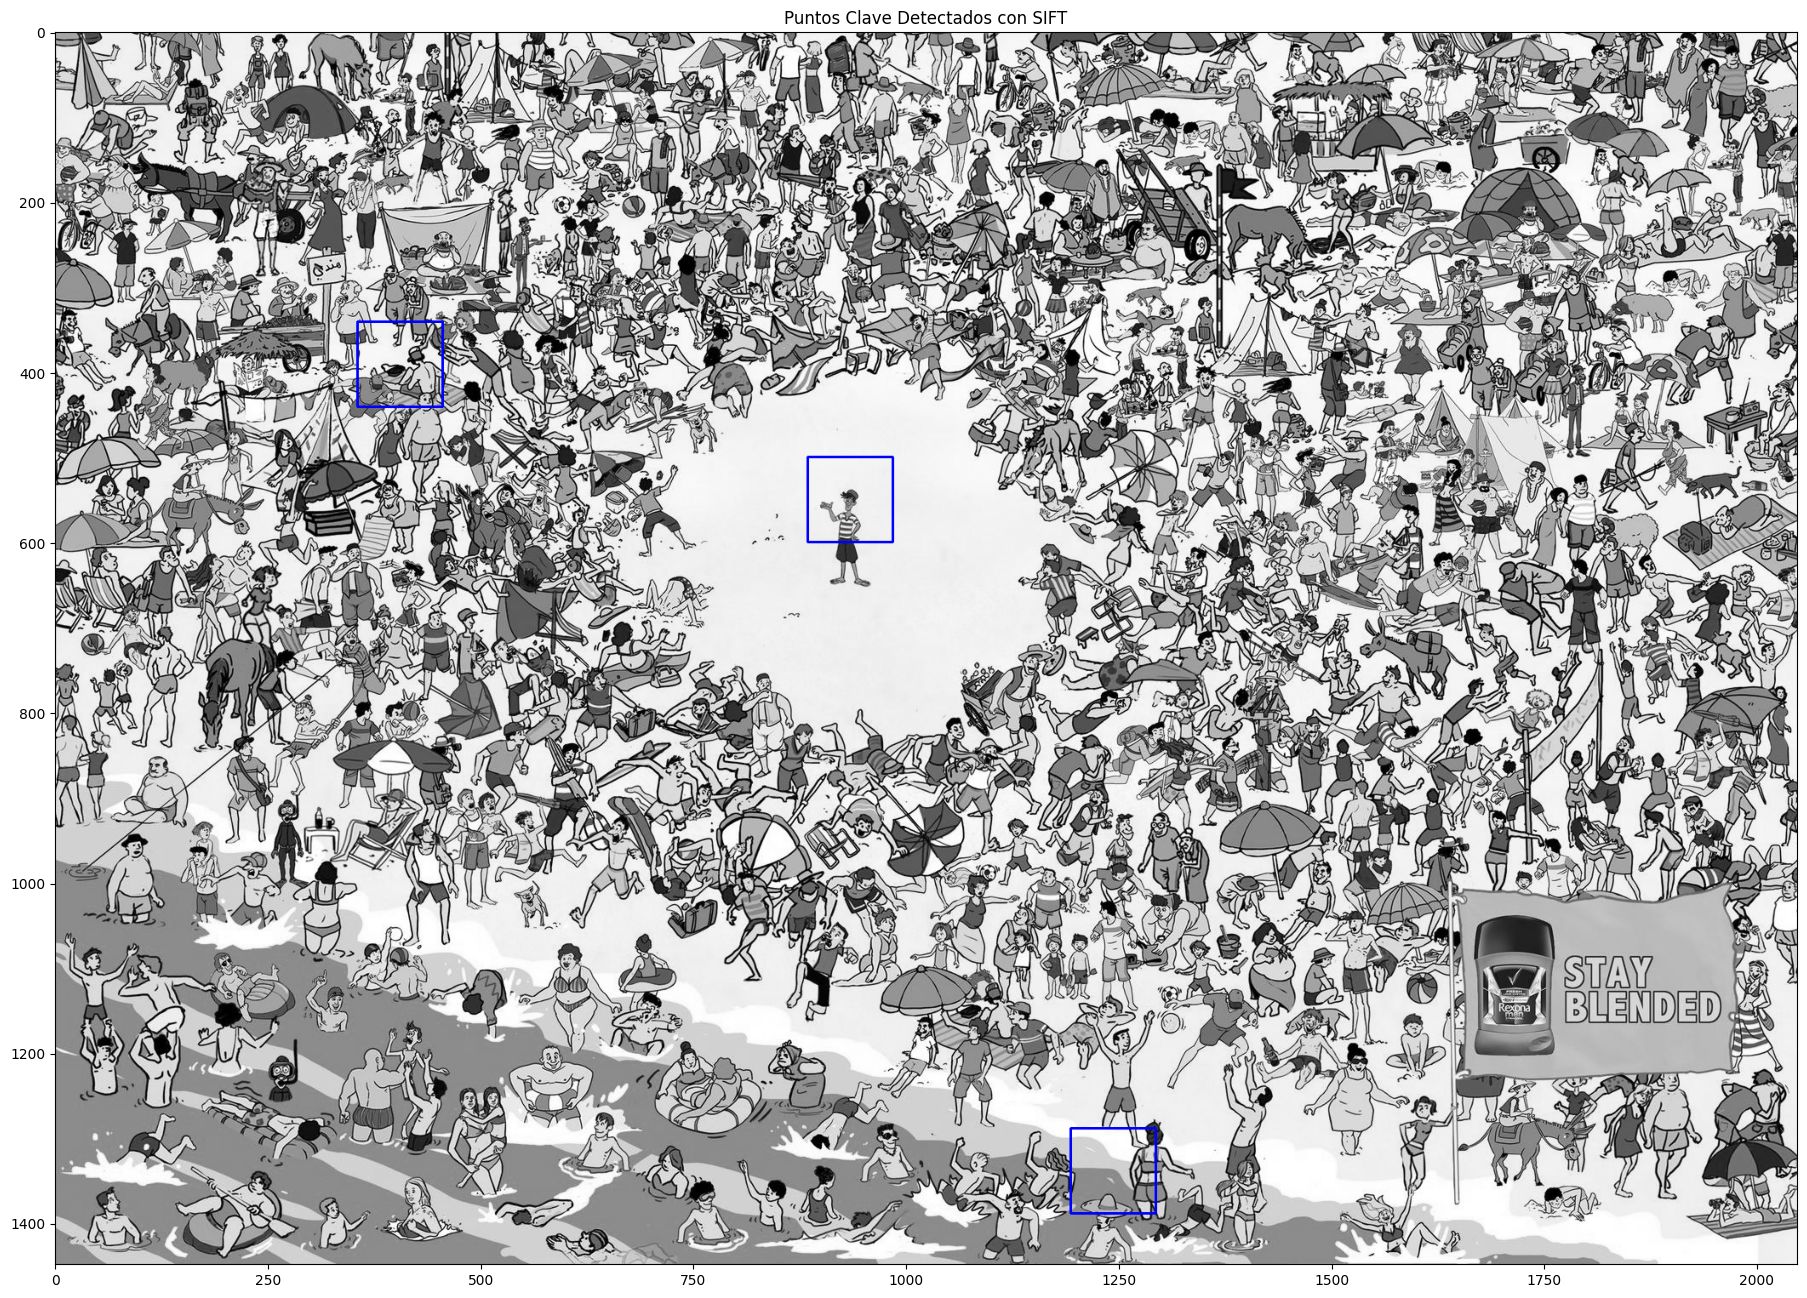

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("output", exist_ok=True)
# Cargar las imágenes
img1 = cv2.imread('images/Objeto_02.png', cv2.IMREAD_GRAYSCALE)  # Imagen del objeto
img2 = cv2.imread('images/Escenario01.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena

# Crear el objeto SIFT
sift = cv2.SIFT_create()

# Detectar puntos clave y calcular descriptores
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Usar BFMatcher para encontrar los mejores matches
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)

# Ordenar los matches por distancia
matches = sorted(matches, key=lambda x: x.distance)

# Dibujar los primeros 10 matches
#img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:15], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
#img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:5], None, flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

# Dibujar cuadrados en la segunda imagen centrados en las coordenadas de los mejores matches
img_with_squares = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)  # Convertir a BGR para dibujar en color
for match in matches[:3]:  # Dibujar cuadrados para los primeros 10 matches
    kp = keypoints2[match.trainIdx]
    x, y = int(kp.pt[0]), int(kp.pt[1])    
    size = int(kp.size)
    
    print("x:", x, "y:", y, "tamano:", size)

    size = 100
    top_left = (x - size // 2, y - size // 2)
    bottom_right = (x + size // 2, y + size // 2)
    cv2.rectangle(img_with_squares, top_left, bottom_right, (255, 0, 0), 2)
    
cv2.imwrite('output/ejemplo_wally.png', img_with_squares)
# Mostrar la imagen con puntos clave
fig, ax = plt.subplots(figsize=(144, 16))
ax.imshow(cv2.cvtColor(img_with_squares, cv2.COLOR_BGR2RGB))
plt.title('Puntos Clave Detectados con SIFT')
plt.show()


x: 1444 y: 1396 size: 1
x: 94 y: 1354 size: 4
x: 630 y: 1370 size: 4
x: 264 y: 1069 size: 4
x: 1326 y: 145 size: 2
x: 1446 y: 1393 size: 5
x: 1482 y: 1395 size: 2
x: 635 y: 1360 size: 2
x: 306 y: 985 size: 2
x: 1757 y: 1280 size: 2


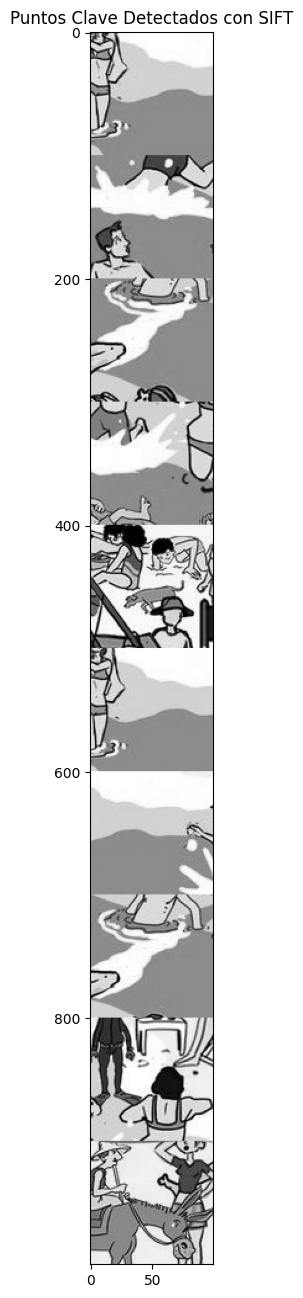

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("output", exist_ok=True)
# Cargar las imágenes
img1 = cv2.imread('images/wally.png', cv2.IMREAD_GRAYSCALE)  # Imagen del objeto
img2 = cv2.imread('images/escenario01.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena

# Crear el objeto SIFT
sift = cv2.SIFT_create()
#sift = cv2.xfeatures2d.SURF_create(hessianThreshold=400)

# Detectar puntos clave y calcular descriptores
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Usar BFMatcher para encontrar los mejores matches
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)

# Ordenar los matches por distancia
matches = sorted(matches, key=lambda x: x.distance)

# Dibujar los primeros 10 matches
#img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:15], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
#img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:5], None, flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

# Dibujar cuadrados en la segunda imagen centrados en las coordenadas de los mejores matches
#img_with_squares = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)  # Convertir a BGR para dibujar en color
#img_with_squares = np.zeros_like(img2)
recortes = []
for match in matches[:10]:  # Dibujar cuadrados para los primeros 10 matches
    kp = keypoints2[match.trainIdx]
    x, y = int(kp.pt[0]), int(kp.pt[1])    
    
    size = int(kp.size)
    
    print("x:", x, "y:", y, "size:", size)

    size = 100
    top_left_x = max(0, x - size // 2)
    top_left_y = max(0, y - size // 2)
    bottom_right_x = min(img2.shape[1], x + size // 2)
    bottom_right_y = min(img2.shape[0], y + size // 2)
    recorte = img2[top_left_y:bottom_right_y, top_left_x:bottom_right_x]
    recortes.append(recorte)

# Crear una imagen en blanco para colocar los recortes
altura_total = sum([recorte.shape[0] for recorte in recortes])
ancho_maximo = max([recorte.shape[1] for recorte in recortes])
img_final = np.zeros((altura_total, ancho_maximo), dtype=img2.dtype)  # ← AQUÍ SE AÑADE img_final

# Colocar los recortes en la imagen final
y_offset = 0
for recorte in recortes:
    img_final[y_offset:y_offset + recorte.shape[0], :recorte.shape[1]] = recorte
    y_offset += recorte.shape[0]

# Mostrar la imagen con puntos clave
fig, ax = plt.subplots(figsize=(144, 16))
ax.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.title('Puntos Clave Detectados con SIFT')
plt.show()




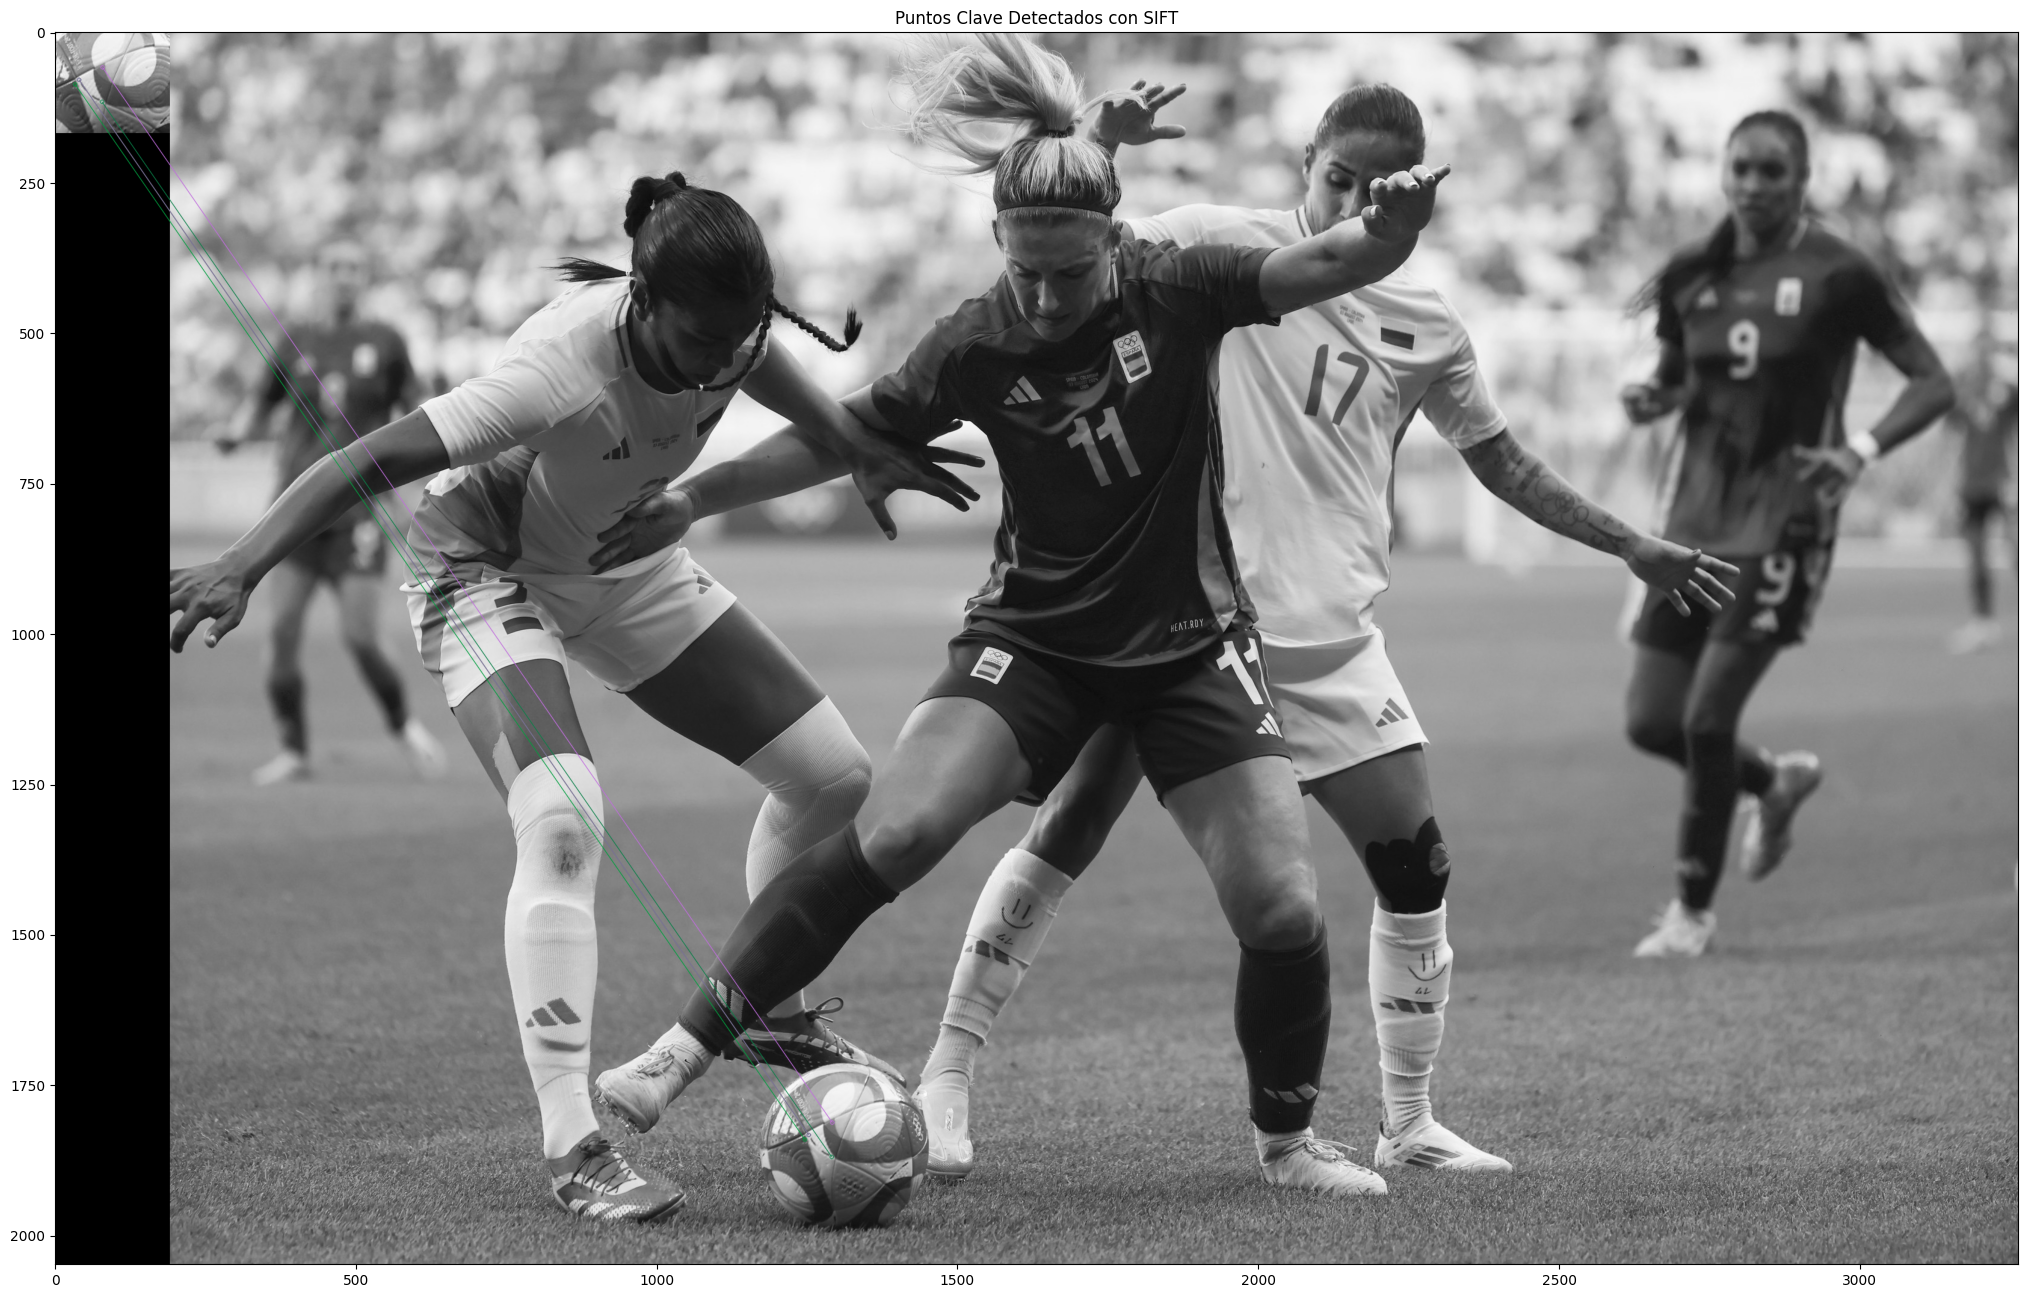

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("output", exist_ok=True)
# Cargar las imágenes
img1 = cv2.imread('images/wally.png', cv2.IMREAD_GRAYSCALE)  # Imagen del objeto
img2 = cv2.imread('images/escenario01.png', cv2.IMREAD_GRAYSCALE)  # Imagen de la escena

# Crear el objeto SIFT
sift = cv2.SIFT_create()

# Detectar puntos clave y calcular descriptores
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Usar BFMatcher para encontrar los mejores matches
bf = cv2.BFMatcher()
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Apply ratio test
good = []
for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append([m])

# Dibujar los primeros 10 matches
#img3 = cv2.drawMatchesKnn(img1,keypoints1,img2,keypoints2,good,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
img3 = cv2.drawMatchesKnn(img1,keypoints1,img2,keypoints2,good,None,flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS)

# Mostrar la imagen con puntos clave
fig, ax = plt.subplots(figsize=(144, 16))
ax.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title('Puntos Clave Detectados con SIFT')
plt.show()


